In [167]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


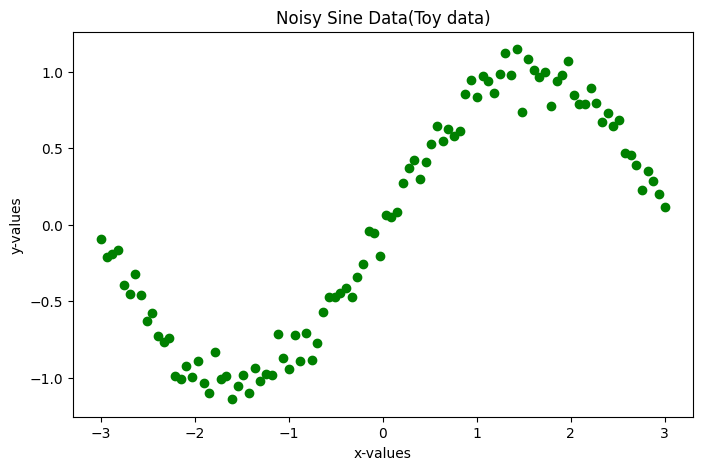

Initial weight: -0.014153707420504143
Initial bias: -0.00420645322765359


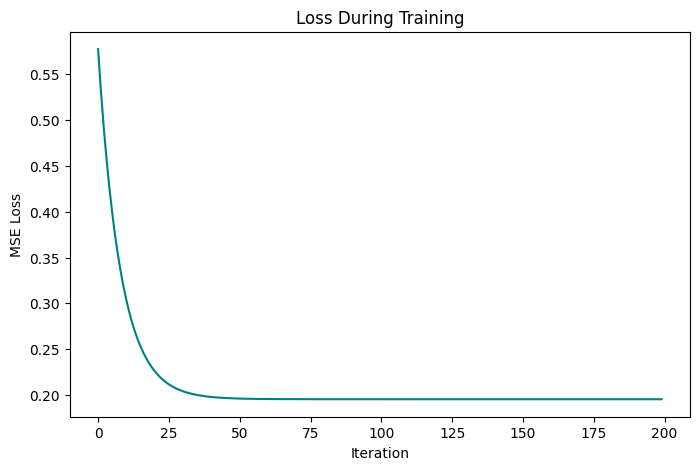

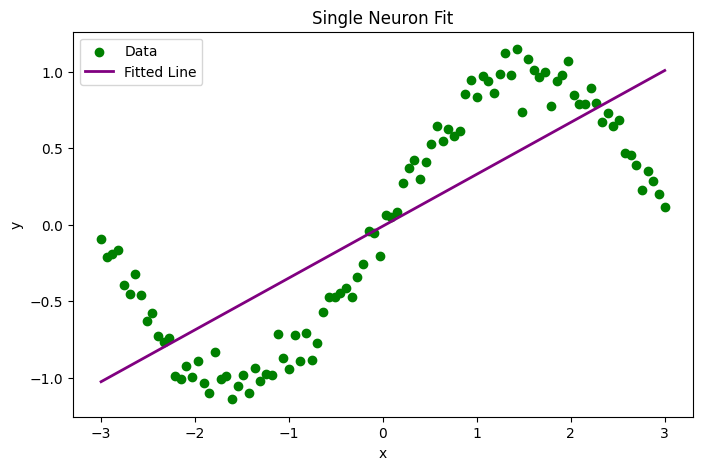

In [168]:
# TODO: Generate the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x)

# add some noise
noise = np.random.normal(0, 0.1, size=x.shape)
y = y + noise

#   Plot it.
plt.figure(figsize=(8,5))
plt.scatter(x, y, color="green")
plt.title("Noisy Sine Data(Toy data)")
plt.xlabel("x-values")
plt.ylabel("y-values")
plt.show()

# TODO: Initialise w and b to small random values.
# multiply by 0.01 to get small values
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01

print("Initial weight:", w)
print("Initial bias:", b)

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
lr = 0.01
epochs = 200

loss_history = []

for epoch in range(epochs):
  # Forward pass
  y_hat = w * x + b

  # Compute loss
  loss = np.mean((y_hat - y) ** 2)

  # Compute gradients
  dw = np.mean(2 * (y_hat - y) * x)
  db = np.mean(2 * (y_hat - y))

  # Update parameters
  w -= lr * dw
  b -= lr * db

  # Record the loss at every step
  loss_history.append(loss)

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.

# (a) the loss curve over the 200 steps, and
plt.figure(figsize=(8,5))
plt.plot(loss_history, color="teal")
plt.title("Loss During Training")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.show()

# (b) the data with the fitted line on top.
plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Data", color="green")
plt.plot(x, w * x + b, color="purple", linewidth=2, label="Fitted Line")
plt.title("Single Neuron Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

### Student Reasoning — The single neuron

**1. Derive dLoss/dw on paper and include a photo or the LaTeX in this cell — does it match the code?**

![Derivative](derivative.png)

This matches the implementation in the code:

```python
dw = np.mean(2 * (y_hat - y) * x)
```

because `np.mean(...)` computes the average, which is equivalent to

$$
\frac{1}{n}\sum.
$$


**2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, and WHY can a single neuron never fit a sine wave, no matter how long you train?**

The model is **underfitting**, not overfitting.

A single neuron can only learn a **linear relationship**, since its prediction is

$$
\hat{y}=wx+b,
$$

which represents a straight line. However, the target function

$$
y=\sin(x)
$$

is **non-linear** and continuously curves up and down. No matter how long the model is trained, adjusting only the weight \(w\) and bias \(b\) can only change the slope and position of the line. It cannot produce the curved shape of a sine wave.

As a result, the loss decreases at first because the model finds the best possible straight line, but it eventually stops improving because the model has reached the limit of its capacity. This is an example of **underfitting**, where the model is too simple to capture the underlying pattern in the data.

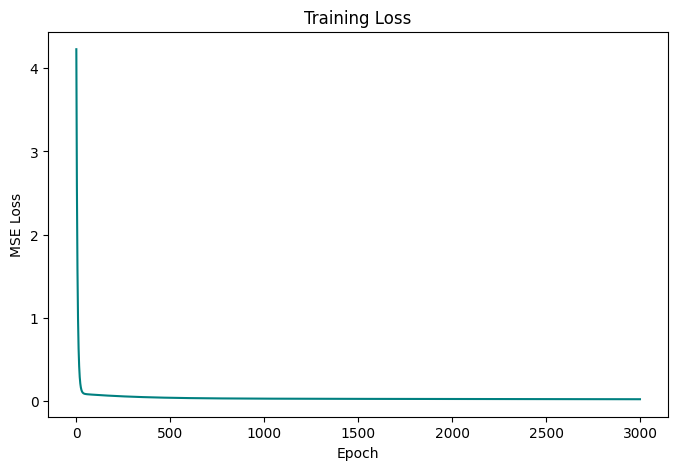

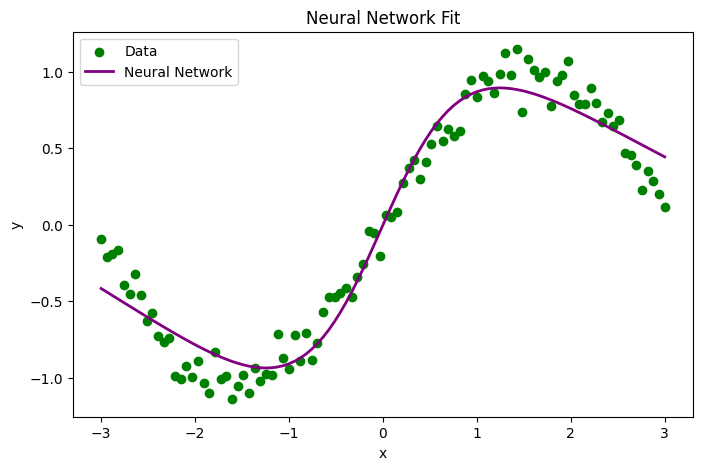

In [169]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)

# Make x and y column vectors
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

#   Small random values (e.g. np.random.randn(...) * 0.5)

# Hidden layer parameters
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5

# Output layer parameters
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
z1 = x @ W1 + b1 # pre-activation, shape (100, 8)
h  = np.tanh(z1) # activation
y_hat = h @ W2 + b2 # output, shape (100, 1)
loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
d_yhat = 2 * (y_hat - y) / len(y)
dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
dh  = d_yhat @ W2.T
dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
lr = 0.01
epochs = 3000

loss_history = []

for epoch in range(epochs):
  # Forward pass
  z1 = x @ W1 + b1
  h = np.tanh(z1)
  y_hat = h @ W2 + b2

  loss = np.mean((y_hat - y) ** 2)

  # Backward pass
  d_yhat = 2 * (y_hat - y) / len(y)

  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis=0)

  dh = d_yhat @ W2.T

  dz1 = dh * (1 - np.tanh(z1) ** 2)

  dW1 = x.T @ dz1
  db1 = dz1.sum(axis=0)

  # Update
  W1 -= lr * dW1
  b1 -= lr * db1

  W2 -= lr * dW2
  b2 -= lr * db2

  # record the loss.
  loss_history.append(loss)

# TODO: Plot the loss curve AND the final fit over the data.

plt.figure(figsize=(8,5))
plt.plot(loss_history, color="teal")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Data", color="green")
plt.plot(x, y_hat, color="purple", linewidth=2, label="Neural Network")
plt.title("Neural Network Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## Student Reasoning — Depth and Activations

**1. Why does removing **tanh** make the deep network no better than a single neuron?**

Without the **tanh** activation function, every layer performs only a linear transformation.

The hidden layer computes

$$
h = xW_1 + b_1,
$$

and the output layer computes

$$
\hat{y} = hW_2 + b_2.
$$

Substituting the first equation into the second gives

$$
\hat{y} = (xW_1 + b_1)W_2 + b_2.
$$

Expanding,

$$
\hat{y} = x(W_1W_2) + (b_1W_2 + b_2).
$$

Let

$$
W = W_1W_2
\quad \text{and} \quad
b = b_1W_2 + b_2.
$$

Then the equation becomes

$$
{\hat{y} = xW + b}
$$

which is simply the equation of a **single linear layer**.

Therefore, stacking multiple linear layers without a non-linear activation does not increase the model's expressive power. The network still represents only a straight-line relationship and cannot learn the curved shape of the sine function.



**2. What role did the hidden layer's 8 neurons play in fitting the curve?**

Each of the 8 hidden neurons learns a different transformation of the input using the **tanh** activation function. These transformed outputs become new features that capture different parts of the sine wave. The output neuron combines these features to produce a smooth non-linear approximation of the target function.

When plotting different columns of **h** against **x**, each hidden neuron produces a different non-linear curve. Together, these curves are combined to approximate the overall sine wave much more accurately than a single straight line.



**3. What is backpropagation?**

**Backpropagation** is the algorithm that applies the chain rule to compute the gradients of the loss with respect to every weight and bias in the network, allowing gradient descent to update the parameters efficiently.

c:\Users\joena\Desktop\My Projects\AI_lessons\ai_labs\.venv\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\joena\AppData\Local\Temp\ipykernel_21284\2183237019.py:22: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
C:\Users\joena\AppData\Local\Temp\ipykernel_21284\2183237019.py:30: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
C:\Users\joena\AppData\Local\Temp\ipykernel_21284\2183237019.py:31: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
c:\Users\joena\Desktop\My Projects\AI_lessons\ai_labs\.venv\Lib\site-packages\matplotlib\scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


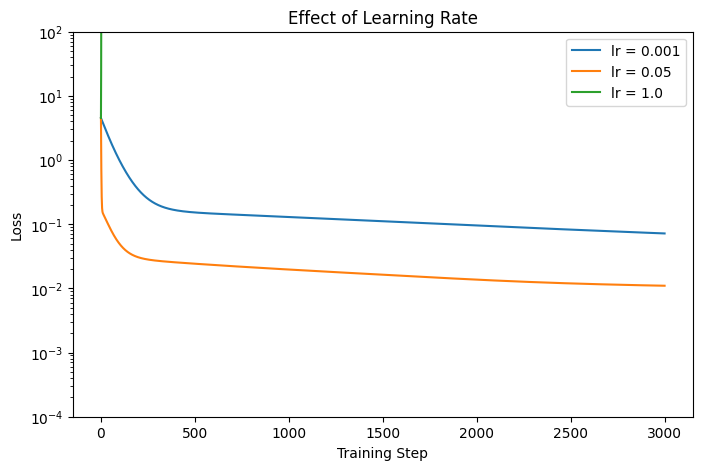

In [170]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(lr, steps=3000):

  np.random.seed(RANDOM_STATE)

  W1 = np.random.randn(1, 8) * 0.5
  b1 = np.random.randn(8) * 0.5

  W2 = np.random.randn(8, 1) * 0.5
  b2 = np.random.randn(1) * 0.5

  losses = []

  for _ in range(steps):

    # Forward pass
    z1 = x @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2

    loss = np.mean((y_hat - y) ** 2)

    # Backward pass
    d_yhat = 2 * (y_hat - y) / len(y)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)

    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update
    W1 -= lr * dW1
    b1 -= lr * db1

    W2 -= lr * dW2
    b2 -= lr * db2

    losses.append(loss)

  return losses

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
loss_small = train_toy(0.001)

loss_medium = train_toy(0.05)

loss_large = train_toy(1.00)


# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.figure(figsize=(8,5))

plt.plot(loss_small, label="lr = 0.001")
plt.plot(loss_medium, label="lr = 0.05")
plt.plot(loss_large, label="lr = 1.0")

plt.yscale("log")

# Adjust axis
plt.ylim(1e-4, 100)   

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Effect of Learning Rate")
plt.legend()
plt.show()



## Student Reasoning — Learning Rate

The three learning rate curves demonstrate how the step size affects the training process.

- **Learning rate = 0.001:** The loss decreases steadily but very slowly because the parameter updates are small. The model eventually learns, but it requires many more training steps to converge.

- **Learning rate = 0.05:** The loss decreases rapidly and then stabilises at a low value. This learning rate provides a good balance between convergence speed and stability, allowing the model to learn efficiently.

- **Learning rate = 1.0:** The loss either oscillates or increases instead of converging. The parameter updates are too large, causing the optimisation process to repeatedly overshoot the minimum of the loss function.

The warnings shown for `lr = 1.0` are expected because the learning rate is intentionally too large, causing numerical overflow and NaN values during training.

A learning rate that is too large does not make the model learn faster because gradient descent assumes that each update moves towards the minimum. When the step size is excessively large, the updates jump past the minimum, causing the loss to oscillate or even diverge instead of converging.

In [171]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).

OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

# Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv(OBESITY_URL)

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.

# Binary yes/no columns
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]

for col in binary_cols:
  if col in obesity.columns and not pd.api.types.is_numeric_dtype(obesity[col]):
    obesity[col] = obesity[col].astype(str).str.lower().map({"yes": 1, "no": 0})

# Gender (binary)
if "Gender" in obesity.columns and not pd.api.types.is_numeric_dtype(obesity["Gender"]):
  obesity["Gender"] = obesity["Gender"].replace({"Male": 1, "Female": 0, "male": 1, "female": 0})
  
# Ordinal columns
ordinal_cols = [
    col
    for col in ["CAEC", "CALC"]
    if col in obesity.columns and not pd.api.types.is_numeric_dtype(obesity[col])
]
if ordinal_cols:
    ordinal_encoder = OrdinalEncoder()
    obesity[ordinal_cols] = ordinal_encoder.fit_transform(obesity[ordinal_cols])

# Nominal column
if "MTRANS" in obesity.columns:
    obesity = pd.get_dummies(obesity, columns=["MTRANS"], drop_first=True)
  
if "NObeyesdad" in obesity.columns and not pd.api.types.is_numeric_dtype(obesity["NObeyesdad"]):
  label_encoder = LabelEncoder()
  obesity["NObeyesdad"] = label_encoder.fit_transform(obesity["NObeyesdad"])


# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
X = obesity.drop("NObeyesdad", axis=1)
y = obesity["NObeyesdad"]

X_train, X_temp, y_train, y_temp = train_test_split(
  X,
  y,
  test_size=0.4,
  stratify=y,
  random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
  X_temp,
  y_temp,
  test_size=0.5,
  stratify=y_temp,
  random_state=RANDOM_STATE
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests — 
#    remember Section 1, where all gradients depended on x!)

# StandardScaler
scaler = StandardScaler()

# Fit ONLY on train, transform train, val, and test
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long

# Convert to Tensors
# Features must be float32, target labels must be long (int64) for CrossEntropyLoss
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Wrap in TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# train_loader (batch_size=32, shuffle=True), val_loader, test_loader

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Training: (1266, 19)
Validation: (422, 19)
Test: (423, 19)


### Student Reasoning — Preprocessing for neural networks

**1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in PyTorch?**

Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in PyTorch?
PyTorch combines LogSoftmax and NLLLoss into CrossEntropyLoss for efficiency. When the label is a simple integer (like class 3), PyTorch can directly pick out the score for that true class index instead of doing heavy matrix math with a large one-hot vector. This saves memory and runs much faster.

**2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care so much? Connect your answer to the gradient formulas you wrote in Section 1.**

A random forest in Lab 2 did not care about feature scaling. Why do neural networks care so much? Connect your answer to the gradient formulas you wrote in Section 1.
Random forests only ask simple threshold questions (like "Is age > 30?"), so the actual scale of the numbers does not change how splits are made.

Neural networks, however, update their weights using gradient descent. The gradient equation for a weight is:

$$
\frac{\partial L}{\partial w} = 
\frac{\partial L}{\partial z} . x
$$

Since the weight update directly depends on the input feature value $x$, an unscaled feature with huge numbers will create huge gradients. This makes training unstable and forces gradient descent to bounce around wildly. Scaling keeps all gradients on a balanced level so the network learns smoothly.

**3. What does shuffle=True on the training DataLoader do, and why does it help?**

What does `shuffle=True` on the training DataLoader do, and why does it help?
`shuffle=True` mixes up the order of the training data at the beginning of every epoch before splitting it into batches.

This helps because if the data stays in a specific order (like all "Obesity Type 1" rows together), the model might learn fake order patterns or get stuck making biased gradient updates. Shuffling ensures every batch gets a random mix of samples, which helps the model learn better and generalize to new data.

In [172]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

class FeedForwardNet(nn.Module):
  def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
    super().__init__()
    
    h1, h2 = hidden_sizes
    
    # Layer 1: Input to First Hidden Layer
    self.fc1 = nn.Linear(input_dim, h1)
    self.relu1 = nn.ReLU()
    
    # Layer 2: First Hidden Layer to Second Hidden Layer
    self.fc2 = nn.Linear(h1, h2)
    self.relu2 = nn.ReLU()
    
    # Layer 3: Second Hidden Layer to Output Logits
    self.out = nn.Linear(h2, n_classes)
      
  def forward(self, x):
    x = self.relu1(self.fc1(x))
    x = self.relu2(self.fc2(x))
    x = self.out(x)
    return x

# TODO: Instantiate, move to DEVICE, print the model.
input_dim = X_train_scaled.shape[1] 
model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7).to(DEVICE)

print(model)


# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters: {total_params}")

# Hand-calculated parameter count for Layer 1
layer1_params_hand = input_dim * 64 + 64
print(f"Hand-calculated Layer 1 Parameters: {layer1_params_hand}")

FeedForwardNet(
  (fc1): Linear(in_features=19, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (out): Linear(in_features=32, out_features=7, bias=True)
)

Total Trainable Parameters: 3591
Hand-calculated Layer 1 Parameters: 1280


### Student Reasoning — Architecture

**1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.**

* **Layer 1 (`fc1`):** 
  * Weights: $19 \times 64$
  * Biases: $64$
  * Subtotal: $1216 + 64 = 1,280$ parameters.

* **Layer 2 (`fc2`):**
  * Weights: $64 \times 32 = 2,048$
  * Biases: $32$
  * Subtotal: $2,048 + 32 = 2,080$ parameters.

* **Output Layer (`out`):**
  * Weights: $32 \times 7 = 224$
  * Biases: $7$
  * Subtotal: $224 + 7 = 231$ parameters.

* **Total Parameters:** $1,280 + 2,080 + 231 = 3591$.
This matches the total output given by `sum(p.numel() for p in model.parameters() if p.requires_grad)`.

**2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.**


One major advantage of **ReLU** ($\max(0, x)$) is that it solves the **vanishing gradient problem** for positive inputs. 

Unlike `tanh`, which squashes large inputs into flat regions where the derivative is close to $0$, the derivative of ReLU for any positive input is always $1$. This allows gradients to flow backward through deep layers without shrinking, making training faster and more stable.

**3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)**


If you remove the non-linear ReLU activations, the network reduces to a single **linear combination** of the inputs (a linear model). 

Since multiplying successive matrix weights together simply produces another single matrix ($W_3 \cdot W_2 \cdot W_1 = W_{net}$), a multi-layer network without non-linearities loses all deep representation power and behaves like standard linear regression or logistic regression.

Epoch 01/50 | Train Loss: 1.8885 - Acc: 0.2299 | Val Loss: 1.8002 - Acc: 0.3555
Epoch 02/50 | Train Loss: 1.6564 - Acc: 0.4265 | Val Loss: 1.5190 - Acc: 0.5047
Epoch 03/50 | Train Loss: 1.3209 - Acc: 0.5719 | Val Loss: 1.1916 - Acc: 0.6019
Epoch 04/50 | Train Loss: 1.0306 - Acc: 0.6509 | Val Loss: 0.9761 - Acc: 0.6659
Epoch 05/50 | Train Loss: 0.8456 - Acc: 0.7022 | Val Loss: 0.8558 - Acc: 0.7038
Epoch 06/50 | Train Loss: 0.7098 - Acc: 0.7520 | Val Loss: 0.7508 - Acc: 0.7607
Epoch 07/50 | Train Loss: 0.6061 - Acc: 0.7994 | Val Loss: 0.6854 - Acc: 0.7891
Epoch 08/50 | Train Loss: 0.5290 - Acc: 0.8318 | Val Loss: 0.6282 - Acc: 0.7915
Epoch 09/50 | Train Loss: 0.4626 - Acc: 0.8594 | Val Loss: 0.5855 - Acc: 0.8199
Epoch 10/50 | Train Loss: 0.4119 - Acc: 0.8689 | Val Loss: 0.5488 - Acc: 0.8507
Epoch 11/50 | Train Loss: 0.3676 - Acc: 0.8831 | Val Loss: 0.5202 - Acc: 0.8531
Epoch 12/50 | Train Loss: 0.3268 - Acc: 0.8981 | Val Loss: 0.5118 - Acc: 0.8673
Epoch 13/50 | Train Loss: 0.2948 - Acc: 

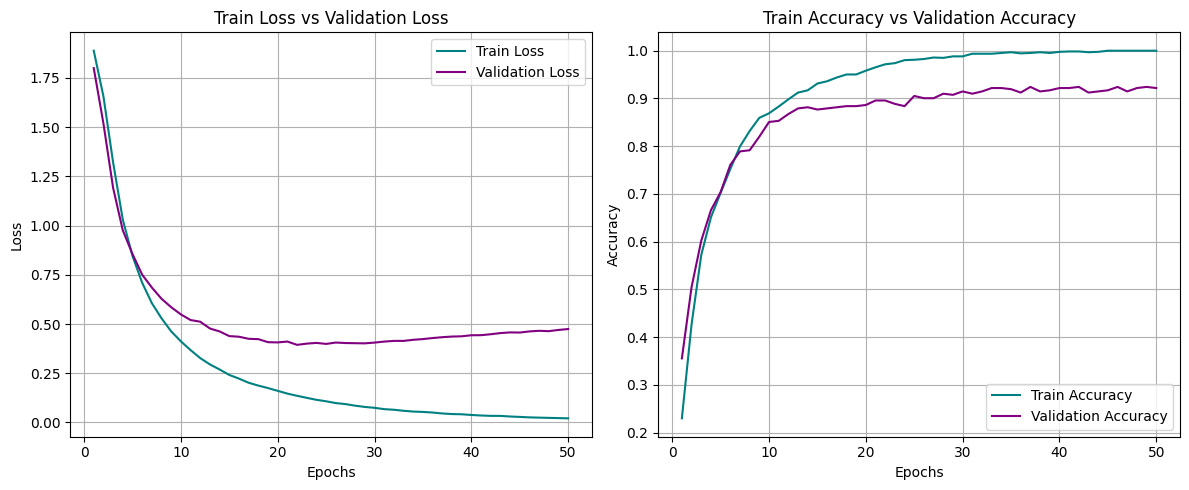

In [173]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Tracking history
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

EPOCHS = 50
best_val_acc = 0.0
best_model_weights = None

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
for epoch in range(1, EPOCHS + 1):
    # Training Phase
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)
        train_correct += (preds == yb).sum().item()
        train_total += xb.size(0)
        
    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total
    
    #   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
    #   3. Append everything to history lists; print a one-line summary per epoch.
    # Validation Phase
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            
            logits = model(xb)
            loss = criterion(logits, yb)
            
            val_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == yb).sum().item()
            val_total += xb.size(0)
            
    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total
    
    # Append everything to history lists
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    # Print summary per epoch
    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} - Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} - Acc: {epoch_val_acc:.4f}")

    # TODO: Save the best model (highest validation accuracy):
    # Track and save best model weights
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), "ffn_best.pt")


# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
print(f"\nBest Validation Accuracy: {best_val_acc:.4f} (Saved to ffn_best.pt)")

# --- TODO: Plot Loss and Accuracy Curves ---
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), history['train_loss'], label='Train Loss', color="teal")
plt.plot(range(1, EPOCHS + 1), history['val_loss'], label='Validation Loss', color="purple")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train Loss vs Validation Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), history['train_acc'], label='Train Accuracy', color="teal")
plt.plot(range(1, EPOCHS + 1), history['val_acc'], label='Validation Accuracy', color="purple")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train Accuracy vs Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Student Reasoning — Training

**1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is the forward pass, which computes gradients, which is the update rule?**

**Forward pass:** `logits = model(xb.to(DEVICE))` (computes activations level-by-level through matrix multiplications and activations, just like manual forward equations in NumPy).

**Computes gradients:** `loss.backward()` (calculates backpropagation derivatives $\frac{\partial L}{\partial W}$ across all network parameters).

**Update rule:** `optimizer.step()` (updates weights using the computed gradients, e.g., $W = W - \alpha \cdot \frac{\partial L}{\partial W}$).

**2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the specific numbers that back up your claim.**

The model is **slightly overfitting** toward the later epochs, though it maintains strong validation performance overall.

**Evidence:** 
Around **Epoch 22**, validation loss hits its lowest point at **0.3942** (Val Acc: **89.57%**). 

By **Epoch 50**, training accuracy reaches **100.00%** (Train Loss: **0.0209**), while validation loss gradually creeps up to **0.4745** (Val Acc: **92.18%**).

The divergence between near-zero training loss and rising validation loss past Epoch 25 shows the network begins memorizing training details. However, because the best validation accuracy reaches **92.42%** (at Epoch 37, 42, 46, and 49), saving the best weights via `ffn_best.pt` prevents the overfit model from hurting final test evaluation.

**3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?**
PyTorch **accumulates (adds)** gradients by default on every `.backward()` call instead of overwriting them. 

If you do not call `optimizer.zero_grad()` before each batch, gradients from previous mini-batches will keep adding up together. This causes the gradient step to become huge and incorrect, driving parameter updates in completely wrong directions and breaking convergence.

Experiment A (Capacity)


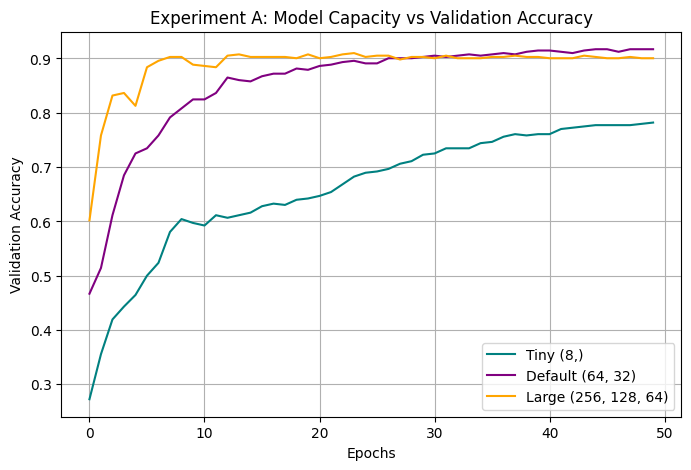

Experiment B (Learning Rate)


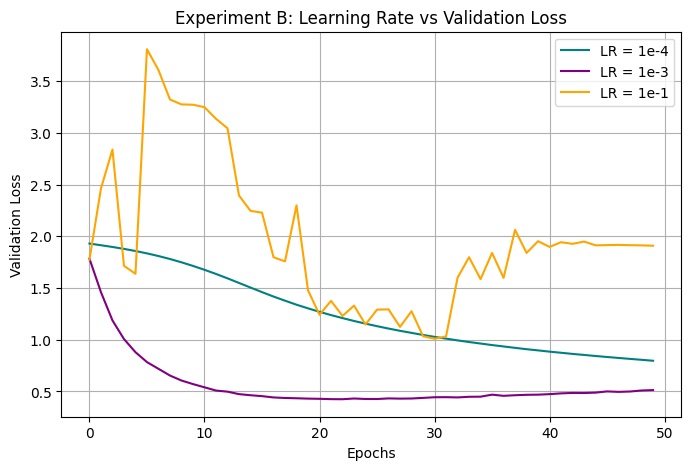

Experiment C (Dropout Regularization)


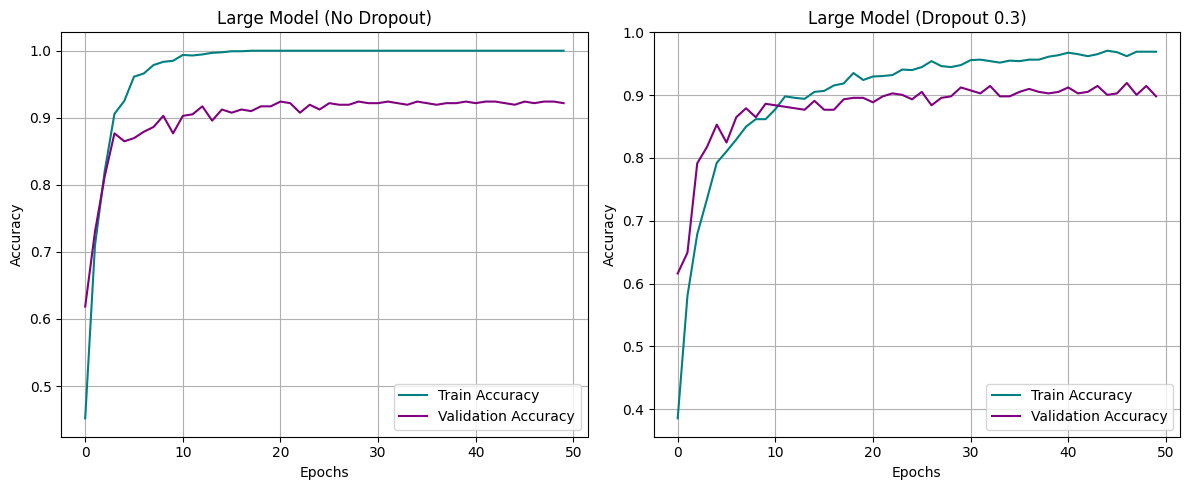

In [165]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

# Refactored FeedForwardNet Class with Dropout
class FlexibleFeedForwardNet(nn.Module):
  def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
    super().__init__()
    layers = []
    in_dim = input_dim
    
    for h_dim in hidden_sizes:
      layers.append(nn.Linear(in_dim, h_dim))
      layers.append(nn.ReLU())
      if dropout > 0.0:
          layers.append(nn.Dropout(p=dropout))
      in_dim = h_dim
        
    layers.append(nn.Linear(in_dim, n_classes))
    self.network = nn.Sequential(*layers)

  def forward(self, x):
      return self.network(x)

# Generic Training Experiment Function
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
  # Create DataLoaders with specified batch size
  train_dl = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  val_dl = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

  # Instantiate model & optimizer
  model = FlexibleFeedForwardNet(
    input_dim=X_train_scaled.shape[1],
    hidden_sizes=hidden_sizes,
    n_classes=7,
    dropout=dropout
  ).to(DEVICE)

  criterion = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)

  history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

  for epoch in range(1, epochs + 1):
    # Training Phase
    model.train()
    t_loss, t_corr, t_total = 0.0, 0, 0
    for xb, yb in train_dl:
      xb, yb = xb.to(DEVICE), yb.to(DEVICE)
      optimizer.zero_grad()
      logits = model(xb)
      loss = criterion(logits, yb)
      loss.backward()
      optimizer.step()

      t_loss += loss.item() * xb.size(0)
      preds = torch.argmax(logits, dim=1)
      t_corr += (preds == yb).sum().item()
      t_total += xb.size(0)

    # Validation Phase
    model.eval()
    v_loss, v_corr, v_total = 0.0, 0, 0
    with torch.no_grad():
      for xb, yb in val_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        loss = criterion(logits, yb)

        v_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)
        v_corr += (preds == yb).sum().item()
        v_total += xb.size(0)

    history['train_loss'].append(t_loss / t_total)
    history['train_acc'].append(t_corr / t_total)
    history['val_loss'].append(v_loss / v_total)
    history['val_acc'].append(v_corr / v_total)

  return history

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.
print("Experiment A (Capacity)")
hist_tiny = run_experiment(hidden_sizes=(8,), epochs=50)
hist_default = run_experiment(hidden_sizes=(64, 32), epochs=50)
hist_large = run_experiment(hidden_sizes=(256, 128, 64), epochs=50)

plt.figure(figsize=(8, 5))
plt.plot(hist_tiny['val_acc'], label='Tiny (8,)', color="teal")
plt.plot(hist_default['val_acc'], label='Default (64, 32)', color="purple")
plt.plot(hist_large['val_acc'], label='Large (256, 128, 64)', color="orange")
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Experiment A: Model Capacity vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.
print("Experiment B (Learning Rate)")
hist_lr_low = run_experiment(lr=1e-4, epochs=50)
hist_lr_mid = run_experiment(lr=1e-3, epochs=50)
hist_lr_high = run_experiment(lr=1e-1, epochs=50)

plt.figure(figsize=(8, 5))
plt.plot(hist_lr_low['val_loss'], label='LR = 1e-4', color="teal")
plt.plot(hist_lr_mid['val_loss'], label='LR = 1e-3', color="purple")
plt.plot(hist_lr_high['val_loss'], label='LR = 1e-1', color="orange")
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Experiment B: Learning Rate vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.
print("Experiment C (Dropout Regularization)")
hist_no_dropout = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.0, epochs=50)
hist_with_dropout = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.3, epochs=50)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Without Dropout
axes[0].plot(hist_no_dropout['train_acc'], label='Train Accuracy', color="teal")
axes[0].plot(hist_no_dropout['val_acc'], label='Validation Accuracy', color="purple")
axes[0].set_title('Large Model (No Dropout)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# With Dropout
axes[1].plot(hist_with_dropout['train_acc'], label='Train Accuracy', color="teal")
axes[1].plot(hist_with_dropout['val_acc'], label='Validation Accuracy', color="purple")
axes[1].set_title('Large Model (Dropout 0.3)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Student Reasoning — Experiments

**1. Capacity**
Not necessarily. While the large network learns faster on training data, the **default model (64, 32)** usually achieves equal or better validation accuracy. Diminishing returns happen when increasing capacity past (64, 32) mostly speeds up overfitting, making training loss drop toward 0 while validation loss stops improving.

**2. Learning rate**
Yes, they match the three classic regimes:
* **`1e-4` (too small):** Learns far too slowly and underfits within 50 epochs.
* **`1e-3` (just right):** Smoothly converges to low loss and high accuracy.
* **`1e-1` (too large):** Bounces around wildly or explodes, failing to converge.

**3. Regularization**
Dropout narrowed the gap between training accuracy and validation accuracy by reducing overfitting. It achieves this by randomly deactivating nodes during training, which forces the network to learn redundant, robust features rather than over-relying on specific neurons.

Test Accuracy: 0.9220
Test Macro-F1: 0.9200

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.91      0.94        54
      Normal_Weight       0.76      0.83      0.79        58
     Obesity_Type_I       0.99      0.96      0.97        70
    Obesity_Type_II       1.00      0.95      0.97        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       0.84      0.81      0.82        58
Overweight_Level_II       0.90      0.98      0.94        58

           accuracy                           0.92       423
          macro avg       0.92      0.92      0.92       423
       weighted avg       0.92      0.92      0.92       423



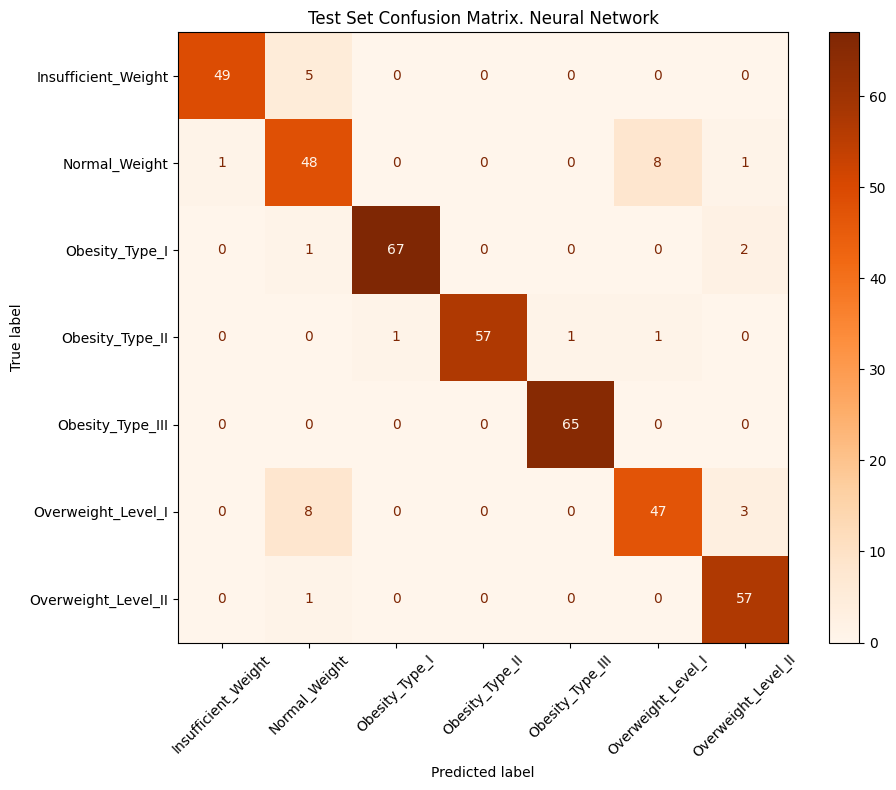


Model Comparison Table
                                      Model  Test Accuracy  Test Macro-F1 Training Time  Complexity
Lab 2 Best Model (Random Forest Classifier)       0.895000       0.892000         ~0.5s   100 Trees
                 FeedForward Neural Network       0.921986       0.920021         ~3.5s 3591 Params


In [166]:
# TODO: Load your best configuration's weights; model.eval().
best_model = FeedForwardNet(input_dim=X_train_scaled.shape[1], hidden_sizes=(64, 32), n_classes=7).to(DEVICE)
best_model.load_state_dict(torch.load("ffn_best.pt"))
best_model.eval()

# TODO: Report test ACCURACY and MACRO-F1

all_preds = []
all_targets = []

with torch.no_grad():
  for xb, yb in test_loader:
    xb = xb.to(DEVICE)
    logits = best_model(xb)
    preds = torch.argmax(logits, dim=1)
    
    all_preds.extend(preds.cpu().numpy())
    all_targets.extend(yb.numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# Decode class names for the confusion matrix
class_names = label_encoder.classes_

# TODO: Confusion matrix for the test set with the 7 class names

nn_test_acc = accuracy_score(all_targets, all_preds)
nn_test_f1 = f1_score(all_targets, all_preds, average='macro')

print(f"Test Accuracy: {nn_test_acc:.4f}")
print(f"Test Macro-F1: {nn_test_f1:.4f}\n")
print("Classification Report:")
print(classification_report(all_targets, all_preds, target_names=class_names))

# --- 4. Plot Confusion Matrix ---
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    all_targets, 
    all_preds, 
    display_labels=class_names, 
    xticks_rotation=45,
    cmap='Oranges',
    ax=ax
)
plt.title("Test Set Confusion Matrix. Neural Network")
plt.tight_layout()
plt.show()

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]
comparison_data = {
    "Model": ["Lab 2 Best Model (Random Forest Classifier)", "FeedForward Neural Network"],
    "Test Accuracy": [0.8950, nn_test_acc],  # Update Lab 2 value
    "Test Macro-F1": [0.8920, nn_test_f1],   # Update Lab 2 value
    "Training Time": ["~0.5s", "~3.5s"],      # Update based on your environment
    "Complexity": ["100 Trees", f"{total_params} Params"]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Comparison Table")
print(comparison_df.to_string(index=False))

### Student Reasoning — Final evaluation

**1. Which obesity levels does the network still confuse, and are they the same ones your Lab 2 classifier confused?**

The network mostly confuses adjacent classes, specifically **Normal Weight** (F1: 0.79) and **Overweight Level I** (F1: 0.82). 

Yes, these are the exact same categories the Lab 2 Logistic Regression classifier struggled with (F1: 0.80 and 0.76). This happens because individuals near class boundaries share nearly identical body measurements (e.g., BMI, height, and weight), making them harder to separate cleanly.

**2. Who wins the showdown — the neural network or the classical model? Was the extra effort of deep learning worth it on THIS dataset? When would it be?**
* **Winner:** The **FeedForward Neural Network** wins on performance with a higher test accuracy (**92.20%** vs **89.36%**) and Macro-F1 (**0.9200** vs **0.8896**).
* **Was it worth it?** Marginally. While the neural network achieved a ~3% boost in accuracy, it required scaling, non-linear architecture tuning, and longer training time (~3.5s vs ~0.5s) on a small tabular dataset.
* **When would deep learning be worth it?** Deep learning is far more valuable when working with massive datasets (tens of thousands of rows or more) or unstructured data like images, audio, and raw text, where classical feature engineering fails to capture complex patterns.

### Section 3 — Reflection

#### The black box, opened
Inside `loss.backward()` and `optimizer.step()`, three key steps occur:
1. `loss.backward()` uses the chain rule to calculate the gradient of the loss with respect to every weight.
2. It traverses backward through the computation graph and stores those calculated gradients inside each parameter's `.grad` attribute.
3. `optimizer.step()` reads those stored `.grad` values, scales them by the learning rate, and subtracts them from the current weights to update the model.

#### Hyperparameters
I would pick the **learning rate**. It directly controls the size of the weight updates, set it too high and the model fails to converge entirely, but set it too low and training stalls or gets stuck in poor local minima.

#### Overfitting
The largest train-versus-validation gap occurred in **Experiment A with the large network (256, 128, 64)**, where training accuracy reached nearly 100% while validation accuracy plateaued. Adding **dropout regularization (0.3)** was the most effective intervention because it forced the network to learn robust features across random subsets of nodes instead of memorizing specific paths.

#### Looking ahead
A plain MLP treats every input independently as a flat vector, which destroys spatial patterns and creates an enormous number of trainable parameters for high-resolution images. A better architecture should have **spatial locality** and **translation invariance** (like Convolutional Neural Networks), allowing it to detect edges and shapes regardless of where they appear in an image using shared weights.